## HW 2 Classification and Potential Problems in Linear Regression


In [1]:
"""
Regression Diagnostics: Illustrating Three Common Issues
- Non-linearity
- Outliers
- Collinearity
"""

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.pipeline import make_pipeline

rng = np.random.default_rng(42)

# ── Figure styling ──────────────────────────────────────────────────────────
plt.rcParams.update({
    "figure.facecolor": "#f8f9fa",
    "axes.facecolor": "#f8f9fa",
    "axes.spines.top": False,
    "axes.spines.right": False,
    "font.size": 10,
})

COLORS = dict(data="#4C72B0", fit="#DD8452", resid="#55A868", outlier="#C44E52")




### Issue 1: Non-linearity of the response-predictor relationships

In an ideal world, you can draw a straight line showing the relationship between predictor and response variables. It allows you, the analyst, to most clearly see how a change in quantity of one variable directly relates to the change in another. However, often times data relationships do not work like that. We may have situations where there is an exponential growth and then flattening as the predictor increases. Other times we may have such a dense cloud of data that merely eye-balling the scatter plot is to difficult to see a specific trend line. It is important to understand how to address non-linear relationships since finding the right model can drastically change how effective you can make future predictions. 

We can detect non-linearity by simply evaluating the data distribution on a residiual plot, and attempting to fit a linear regression line on it. If there is poor fit between the linear model and the data, then chances are its a non-linear relationship. A good way to address this issue is to use a quadratic model instead.

Q1) How can you determine that a plot of data actually does have a linear relationship, just that the slope is very small?

Plot Caption: The plots below shows how non-linear relationships can be plotted and then corrected for when modeling predictor-response outcomes. It begins with a linear model and plot, and then progresses to a residual plotting system. 

FileNotFoundError: [Errno 2] No such file or directory: '/mnt/user-data/outputs/1_nonlinearity.png'

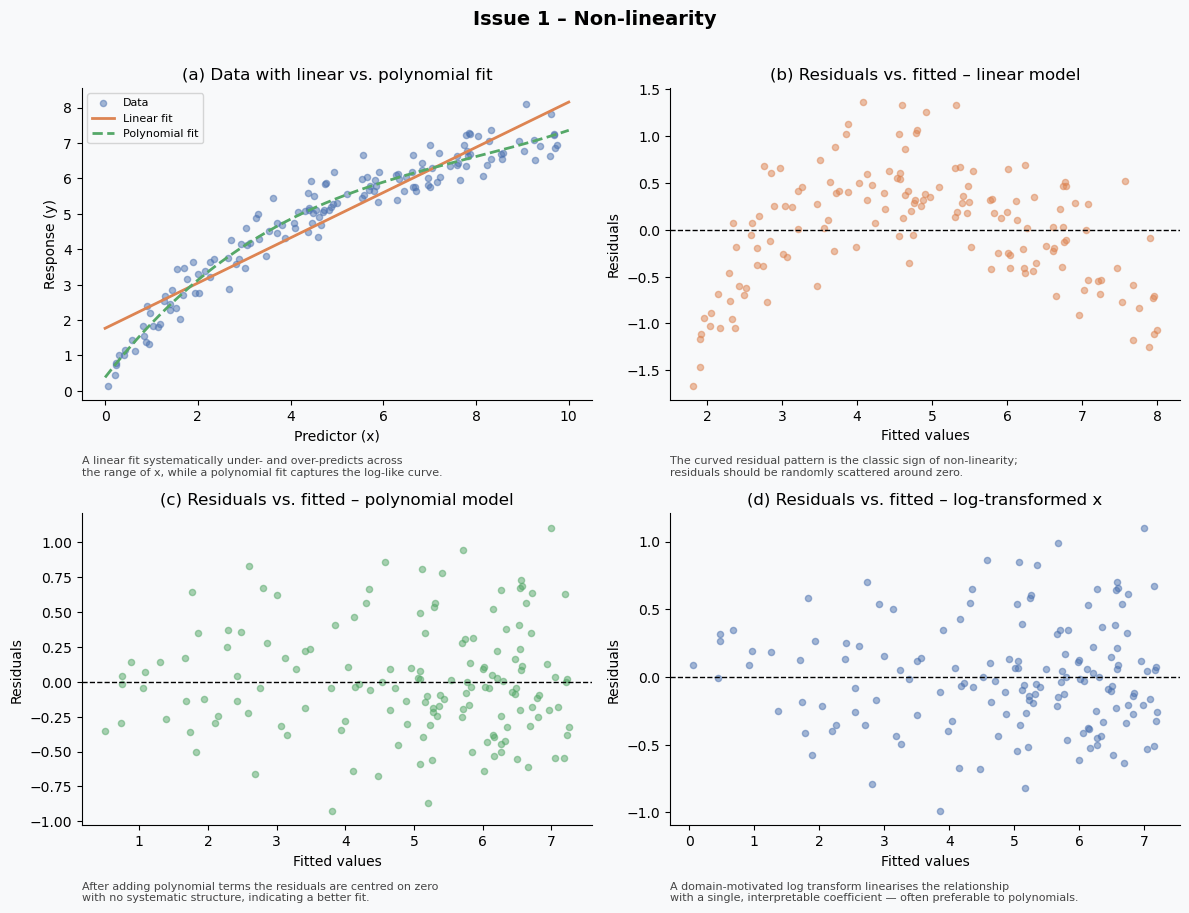

In [2]:
# ════════════════════════════════════════════════════════════════════════════
# 1. NON-LINEARITY
# ════════════════════════════════════════════════════════════════════════════

n = 150
x_nl = rng.uniform(0, 10, n)
# True relationship: log-linear (common in environmental science, e.g. species–area)
y_nl = 3 * np.log1p(x_nl) + rng.normal(0, 0.4, n)

lin_model = LinearRegression().fit(x_nl.reshape(-1, 1), y_nl)
poly_model = make_pipeline(PolynomialFeatures(3), LinearRegression())
poly_model.fit(x_nl.reshape(-1, 1), y_nl)

x_grid = np.linspace(0, 10, 300).reshape(-1, 1)
y_lin_pred = lin_model.predict(x_grid)
y_poly_pred = poly_model.predict(x_grid)

resid_lin = y_nl - lin_model.predict(x_nl.reshape(-1, 1))
resid_poly = y_nl - poly_model.predict(x_nl.reshape(-1, 1))
yhat_lin = lin_model.predict(x_nl.reshape(-1, 1))
yhat_poly = poly_model.predict(x_nl.reshape(-1, 1))

fig1, axes = plt.subplots(2, 2, figsize=(12, 9))
fig1.suptitle("Issue 1 – Non-linearity", fontsize=14, fontweight="bold", y=1.01)

# (a) data + fits
ax = axes[0, 0]
ax.scatter(x_nl, y_nl, s=20, alpha=0.5, color=COLORS["data"], label="Data")
ax.plot(x_grid, y_lin_pred, color=COLORS["fit"], lw=2, label="Linear fit")
ax.plot(x_grid, y_poly_pred, color=COLORS["resid"], lw=2, ls="--", label="Polynomial fit")
ax.set_xlabel("Predictor (x)"); ax.set_ylabel("Response (y)")
ax.set_title("(a) Data with linear vs. polynomial fit")
ax.legend(fontsize=8)
ax.text(0, -0.18, "A linear fit systematically under- and over-predicts across\n"
        "the range of x, while a polynomial fit captures the log-like curve.",
        transform=ax.transAxes, fontsize=8, va="top", color="#444")

# (b) residuals – linear
ax = axes[0, 1]
ax.scatter(yhat_lin, resid_lin, s=20, alpha=0.5, color=COLORS["fit"])
ax.axhline(0, color="black", lw=1, ls="--")
ax.set_xlabel("Fitted values"); ax.set_ylabel("Residuals")
ax.set_title("(b) Residuals vs. fitted – linear model")
ax.text(0, -0.18, "The curved residual pattern is the classic sign of non-linearity;\n"
        "residuals should be randomly scattered around zero.",
        transform=ax.transAxes, fontsize=8, va="top", color="#444")

# (c) residuals – polynomial
ax = axes[1, 0]
ax.scatter(yhat_poly, resid_poly, s=20, alpha=0.5, color=COLORS["resid"])
ax.axhline(0, color="black", lw=1, ls="--")
ax.set_xlabel("Fitted values"); ax.set_ylabel("Residuals")
ax.set_title("(c) Residuals vs. fitted – polynomial model")
ax.text(0, -0.18, "After adding polynomial terms the residuals are centred on zero\n"
        "with no systematic structure, indicating a better fit.",
        transform=ax.transAxes, fontsize=8, va="top", color="#444")

# (d) log-transform approach
ax = axes[1, 1]
log_x = np.log1p(x_nl)
log_model = LinearRegression().fit(log_x.reshape(-1, 1), y_nl)
resid_log = y_nl - log_model.predict(log_x.reshape(-1, 1))
yhat_log = log_model.predict(log_x.reshape(-1, 1))
ax.scatter(yhat_log, resid_log, s=20, alpha=0.5, color=COLORS["data"])
ax.axhline(0, color="black", lw=1, ls="--")
ax.set_xlabel("Fitted values"); ax.set_ylabel("Residuals")
ax.set_title("(d) Residuals vs. fitted – log-transformed x")
ax.text(0, -0.18, "A domain-motivated log transform linearises the relationship\n"
        "with a single, interpretable coefficient — often preferable to polynomials.",
        transform=ax.transAxes, fontsize=8, va="top", color="#444")

fig1.tight_layout()
fig1.savefig("/mnt/user-data/outputs/1_nonlinearity.png", dpi=150, bbox_inches="tight")
plt.close(fig1)
print("Saved: 1_nonlinearity.png")



### Issue 2: Outliers

Outliers, as the name would imply, are data points far away from the model's predicted value. These are a problem because they can be an indication of anything from poor data collection, to some unexpected relationship between the variables at a specific value. While some calculations will experience minimal change with the presence of outliers, they can still have noticble impact on the RSE. To address this, we can either simply remove the data point if we are able to determine its an outlier because of poor collection, or the more robust approach is to create a residual plot utilizing the studentized residuals. 

Q2) At what amount, maybe as a percentage of total data points, should you start thinking of outliers as an indication that there is poor model fit?

Plot Caption: Below is a set of three plots addressing outliers in data modeling. First is just a linear model with outliers, then plotting residuals vs fitted data, and the third is an unexpected plot showing Cook's distance, which apparently shows each point's influence on the fitted values.

FileNotFoundError: [Errno 2] No such file or directory: '/mnt/user-data/outputs/2_outliers.png'

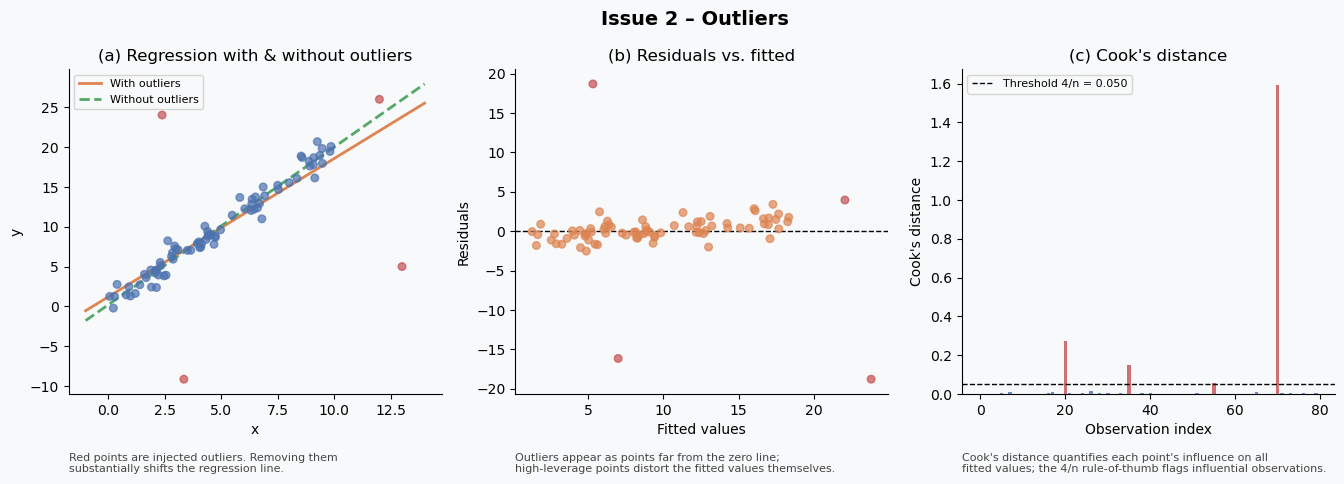

In [5]:
# ════════════════════════════════════════════════════════════════════════════
# 2. OUTLIERS
# ════════════════════════════════════════════════════════════════════════════

n = 80
x_out = rng.uniform(0, 10, n)
y_out = 2 * x_out + rng.normal(0, 1, n)

# Inject 4 outliers: mix of high-leverage and high-residual
outlier_idx = [20, 35, 55, 70]
y_out[20] += 18       # high residual, average leverage
y_out[35] -= 15       # high residual, average leverage
x_out[55] = 12        # high leverage point (x far out)
y_out[55] = 24 + 2    # roughly on the line → influential but not residual-large
x_out[70] = 13        # high leverage + high residual
y_out[70] = 5

mask = np.ones(n, bool); mask[outlier_idx] = False

model_all   = LinearRegression().fit(x_out.reshape(-1, 1), y_out)
model_clean = LinearRegression().fit(x_out[mask].reshape(-1, 1), y_out[mask])

x_g = np.linspace(-1, 14, 300).reshape(-1, 1)
resid_all = y_out - model_all.predict(x_out.reshape(-1, 1))

# Cook's distance (manual, fast)
def cooks_d(X, y):
    n_, p = X.shape
    beta = np.linalg.lstsq(X, y, rcond=None)[0]
    yhat = X @ beta
    resid = y - yhat
    mse = np.sum(resid**2) / (n_ - p)
    H = X @ np.linalg.pinv(X.T @ X) @ X.T
    h = np.diag(H)
    return resid**2 * h / (p * mse * (1 - h)**2)

Xmat = np.column_stack([np.ones(n), x_out])
cd = cooks_d(Xmat, y_out)

fig2, axes = plt.subplots(1, 3, figsize=(14, 5))
fig2.suptitle("Issue 2 – Outliers", fontsize=14, fontweight="bold")

# (a) scatter + both fits
ax = axes[0]
colors_pts = [COLORS["outlier"] if i in outlier_idx else COLORS["data"] for i in range(n)]
ax.scatter(x_out, y_out, s=30, c=colors_pts, alpha=0.7, zorder=3)
ax.plot(x_g, model_all.predict(x_g),   color=COLORS["fit"],   lw=2, label="With outliers")
ax.plot(x_g, model_clean.predict(x_g), color=COLORS["resid"], lw=2, ls="--", label="Without outliers")
ax.set_xlabel("x"); ax.set_ylabel("y")
ax.set_title("(a) Regression with & without outliers")
ax.legend(fontsize=8)
ax.text(0, -0.18, "Red points are injected outliers. Removing them\n"
        "substantially shifts the regression line.",
        transform=ax.transAxes, fontsize=8, va="top", color="#444")

# (b) residuals vs. fitted
ax = axes[1]
yhat_all = model_all.predict(x_out.reshape(-1, 1))
c_pts = [COLORS["outlier"] if i in outlier_idx else COLORS["fit"] for i in range(n)]
ax.scatter(yhat_all, resid_all, s=30, c=c_pts, alpha=0.7, zorder=3)
ax.axhline(0, color="black", lw=1, ls="--")
ax.set_xlabel("Fitted values"); ax.set_ylabel("Residuals")
ax.set_title("(b) Residuals vs. fitted")
ax.text(0, -0.18, "Outliers appear as points far from the zero line;\n"
        "high-leverage points distort the fitted values themselves.",
        transform=ax.transAxes, fontsize=8, va="top", color="#444")

# (c) Cook's distance
ax = axes[2]
bar_colors = [COLORS["outlier"] if cd[i] > 4/n else COLORS["data"] for i in range(n)]
ax.bar(range(n), cd, color=bar_colors, alpha=0.8)
ax.axhline(4/n, color="black", lw=1, ls="--", label=f"Threshold 4/n = {4/n:.3f}")
ax.set_xlabel("Observation index"); ax.set_ylabel("Cook's distance")
ax.set_title("(c) Cook's distance")
ax.legend(fontsize=8)
ax.text(0, -0.18, "Cook's distance quantifies each point's influence on all\n"
        "fitted values; the 4/n rule-of-thumb flags influential observations.",
        transform=ax.transAxes, fontsize=8, va="top", color="#444")

fig2.tight_layout()
fig2.savefig("/mnt/user-data/outputs/2_outliers.png", dpi=150, bbox_inches="tight")
plt.close(fig2)
print("Saved: 2_outliers.png")



### Issue 3: Collinearity

Collinearity is when two or more predictor variables are closely related to one another. What this means is that the collinear variables are so similar that it is difficult to determine their individual effects on the response. This can prove difficult to address with regression models, and can cause the standard error to grow for the model. To address colllinearity, first you can detect if its present by looking at the correlation matrix for the predictors. However, if three or more predictor variables are collinear, then you will need to calculate the variance inflation factor (VIF). Once the collinear variables have been found, we can either drop one (and since the variables themselves have extremely close effects on the response, this shouldn't be an issue) variable, or combine them. 

Q3) While collinear variables may have similar impact on the response, are there instance where multi-variable models can change when you drop one collinear variable over another?

Plot Caption: The plots below show collinearity and how to identify the variables via bootstrapping and VIF. It shows that the collinear variables have much higher VIF scores than the independent variables. 

FileNotFoundError: [Errno 2] No such file or directory: '/mnt/user-data/outputs/3_collinearity.png'

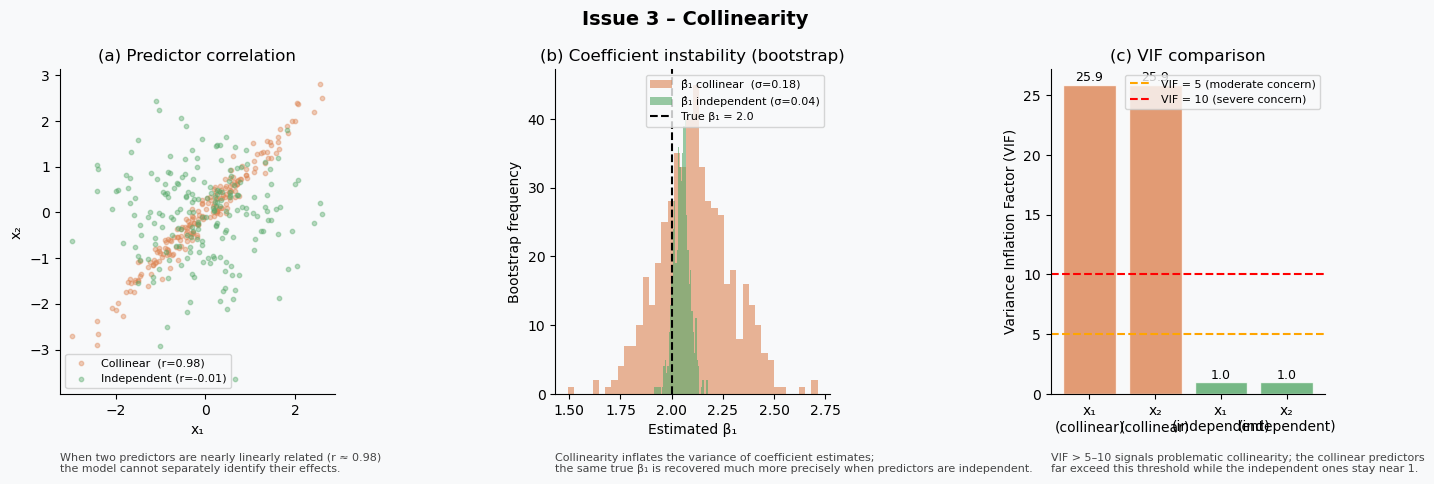

In [4]:
# ════════════════════════════════════════════════════════════════════════════
# 3. COLLINEARITY
# ════════════════════════════════════════════════════════════════════════════

n = 200
x1 = rng.normal(0, 1, n)
# x2 is nearly a linear function of x1 (r ≈ 0.98)
x2_collinear = 0.98 * x1 + rng.normal(0, 0.2, n)
x2_independent = rng.normal(0, 1, n)

true_beta = np.array([1.0, 2.0, 1.5])   # intercept, x1, x2
y_coll = true_beta[0] + true_beta[1]*x1 + true_beta[2]*x2_collinear  + rng.normal(0, 0.5, n)
y_indep = true_beta[0] + true_beta[1]*x1 + true_beta[2]*x2_independent + rng.normal(0, 0.5, n)

# Fit both versions 500 times with bootstrap to show coefficient instability
B = 500
betas_coll  = np.zeros((B, 3))
betas_indep = np.zeros((B, 3))

for b in range(B):
    idx = rng.integers(0, n, n)
    X_c = np.column_stack([np.ones(n), x1[idx], x2_collinear[idx]])
    X_i = np.column_stack([np.ones(n), x1[idx], x2_independent[idx]])
    betas_coll[b]  = np.linalg.lstsq(X_c, y_coll[idx],  rcond=None)[0]
    betas_indep[b] = np.linalg.lstsq(X_i, y_indep[idx], rcond=None)[0]

# VIF
def vif(X_cols):
    """X_cols: list of 1-D arrays (without intercept)."""
    X = np.column_stack(X_cols)
    vifs = []
    for j in range(X.shape[1]):
        y_j = X[:, j]
        X_j = np.delete(X, j, axis=1)
        r2 = 1 - np.var(y_j - X_j @ np.linalg.lstsq(X_j, y_j, rcond=None)[0]) / np.var(y_j)
        vifs.append(1 / (1 - r2))
    return vifs

vif_coll  = vif([x1, x2_collinear])
vif_indep = vif([x1, x2_independent])

fig3, axes = plt.subplots(1, 3, figsize=(14, 5))
fig3.suptitle("Issue 3 – Collinearity", fontsize=14, fontweight="bold")

# (a) scatter x1 vs x2
ax = axes[0]
ax.scatter(x1, x2_collinear,   s=10, alpha=0.4, color=COLORS["fit"],   label=f"Collinear  (r={np.corrcoef(x1, x2_collinear)[0,1]:.2f})")
ax.scatter(x1, x2_independent, s=10, alpha=0.4, color=COLORS["resid"], label=f"Independent (r={np.corrcoef(x1, x2_independent)[0,1]:.2f})")
ax.set_xlabel("x₁"); ax.set_ylabel("x₂")
ax.set_title("(a) Predictor correlation")
ax.legend(fontsize=8)
ax.text(0, -0.18, "When two predictors are nearly linearly related (r ≈ 0.98)\n"
        "the model cannot separately identify their effects.",
        transform=ax.transAxes, fontsize=8, va="top", color="#444")

# (b) bootstrap coefficient distributions
ax = axes[1]
ax.hist(betas_coll[:, 1],  bins=40, alpha=0.6, color=COLORS["fit"],   label=f"β̂₁ collinear  (σ={betas_coll[:,1].std():.2f})")
ax.hist(betas_indep[:, 1], bins=40, alpha=0.6, color=COLORS["resid"], label=f"β̂₁ independent (σ={betas_indep[:,1].std():.2f})")
ax.axvline(true_beta[1], color="black", lw=1.5, ls="--", label=f"True β₁ = {true_beta[1]}")
ax.set_xlabel("Estimated β₁"); ax.set_ylabel("Bootstrap frequency")
ax.set_title("(b) Coefficient instability (bootstrap)")
ax.legend(fontsize=8)
ax.text(0, -0.18, "Collinearity inflates the variance of coefficient estimates;\n"
        "the same true β₁ is recovered much more precisely when predictors are independent.",
        transform=ax.transAxes, fontsize=8, va="top", color="#444")

# (c) VIF bar chart
ax = axes[2]
labels = ["x₁\n(collinear)", "x₂\n(collinear)", "x₁\n(independent)", "x₂\n(independent)"]
vif_vals = vif_coll + vif_indep
bar_c = [COLORS["fit"], COLORS["fit"], COLORS["resid"], COLORS["resid"]]
bars = ax.bar(labels, vif_vals, color=bar_c, alpha=0.8, edgecolor="white")
ax.axhline(5,  color="orange", lw=1.5, ls="--", label="VIF = 5 (moderate concern)")
ax.axhline(10, color="red",    lw=1.5, ls="--", label="VIF = 10 (severe concern)")
ax.set_ylabel("Variance Inflation Factor (VIF)")
ax.set_title("(c) VIF comparison")
ax.legend(fontsize=8)
for bar, val in zip(bars, vif_vals):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
            f"{val:.1f}", ha="center", fontsize=9)
ax.text(0, -0.18, "VIF > 5–10 signals problematic collinearity; the collinear predictors\n"
        "far exceed this threshold while the independent ones stay near 1.",
        transform=ax.transAxes, fontsize=8, va="top", color="#444")

fig3.tight_layout()
fig3.savefig("/mnt/user-data/outputs/3_collinearity.png", dpi=150, bbox_inches="tight")
plt.close(fig3)
print("Saved: 3_collinearity.png")

print("\nAll plots saved successfully.")

In a short paragraph (4–6 sentences), reflect on your use of generative AI in this task: which tool did you use, what prompts did you give it, and how many iterations did it take to get working code? Note any mistakes the AI made and how you identified and fixed them.

For this assignment, I used Claude. The only prompts I provided to the AI Tool were the following "I need you to write me Python code which does the following:generates synthetic data that clearly illustrates the issue, produces plots making the issue visually clear, where applicable, produces additional plots showing how the issue can be addressed. Here are the three issues that need addressing 1) Non-linearity of the response-predictor relationships 2) Outliers 3) Collinearity", so there was very little specific prompting throughout the process, as it only took the first iteration to get this working code. I did notice that some of the plots, especially with Collinearity and Outliers, included fixes and identification methods that were not addressed in the reading. If I were to utilize AI tools further, I would give it context into the repository structure I am working with, as well as the reading to limit solutions to those provided.